# 09. Entrenamiento de Modelos Base (XGBoost vs. LightGBM)

Este notebook corresponde a la **Fase 3: Tarea 3.2 - Modelado Predictivo Base**.
El objetivo de esta etapa es establecer nuestra "Línea Base" (Baseline) entrenando los dos algoritmos del estado del arte basados en potenciación del gradiente (Gradient Boosting): **XGBoost** y **LightGBM**, utilizando sus hiperparámetros por defecto.

Haremos competir a ambos modelos bajo las mismas condiciones y evaluaremos su rendimiento utilizando métricas avanzadas de clasificación en el bloque de prueba (Test), el cual nunca han visto. La métrica decisiva para declarar al ganador será el **Área bajo la curva ROC (AUC-ROC)**.

## 1. Carga de Librerías y Matrices Preprocesadas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score
)


BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "datos" / "processed"
FIG_DIR = BASE_DIR / "entregas" / "figuras"
FIG_DIR.mkdir(parents=True, exist_ok=True)


X_TRAIN_PATH = DATA_DIR / "X_train.csv"
X_TEST_PATH = DATA_DIR / "X_test.csv"
Y_TRAIN_PATH = DATA_DIR / "y_train.csv"
Y_TEST_PATH = DATA_DIR / "y_test.csv"

print("Cargando matrices preprocesadas...")
X_train = pd.read_csv(X_TRAIN_PATH, sep=';', decimal=',')
X_test = pd.read_csv(X_TEST_PATH, sep=';', decimal=',')
y_train = pd.read_csv(Y_TRAIN_PATH, sep=';', decimal=',')['target']
y_test = pd.read_csv(Y_TEST_PATH, sep=';', decimal=',')['target']

print(f"\nDimensiones cargadas exitosamente:")
print(f"- X_train: {X_train.shape[0]} filas x {X_train.shape[1]} columnas")
print(f"- y_train: {y_train.shape[0]} registros")
print(f"- X_test : {X_test.shape[0]} filas x {X_test.shape[1]} columnas")
print(f"- y_test : {y_test.shape[0]} registros")

Cargando matrices preprocesadas...

Dimensiones cargadas exitosamente:
- X_train: 7161 filas x 23 columnas
- y_train: 7161 registros
- X_test : 1791 filas x 23 columnas
- y_test : 1791 registros


## 2. Adecuación de Tipos de Datos para Modelado

Para garantizar la máxima compatibilidad de las matrices con ambos algoritmos y evitar advertencias sobre tipos de datos, convertiremos explícitamente las columnas booleanas procedentes de la codificación One-Hot (OHE) de la vegetación a enteros (0 y 1).

In [2]:

cols_bool = [col for col in X_train.columns if X_train[col].dtype == 'bool']
print(f"Columnas booleanas detectadas para conversión: {cols_bool}")

for col in X_train.columns:
    if X_train[col].dtype == 'bool':
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

print("\nValidación de tipos de datos finales:")
print(X_train.dtypes.value_counts())

Columnas booleanas detectadas para conversión: ['veg_Agricola', 'veg_Coniferas', 'veg_Frondosas', 'veg_Matorral', 'veg_Pastizal', 'veg_Urbano_Antropizado', 'veg_Urbano_Otros']

Validación de tipos de datos finales:
float64    16
int32       7
Name: count, dtype: int64


## 3. Entrenamiento del Modelo Base 1: XGBoost

Entrenamos el clasificador **XGBoost (eXtreme Gradient Boosting)** con sus hiperparámetros de fábrica. Establecemos una semilla de aleatoriedad fija (`random_state=42`) para asegurar la total reproducibilidad de los experimentos.

In [3]:
print("Inicializando clasificador XGBoost...")
xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("Entrenando modelo XGBoost...")
xgb_model.fit(X_train, y_train)
print("Entrenamiento de XGBoost completado")


y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

Inicializando clasificador XGBoost...
Entrenando modelo XGBoost...
¡Entrenamiento de XGBoost completado!


C:\Users\marco\miniconda3\envs\ads\lib\site-packages\xgboost\training.py:199: UserWarning: [18:02:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 4. Entrenamiento del Modelo Base 2: LightGBM

Entrenamos el clasificador **LightGBM (Light Gradient Boosting Machine)** utilizando su configuración estándar de fábrica y la misma semilla (`random_state=42`) para garantizar que la competición sea justa y equitativa.

In [4]:
print("Inicializando clasificador LightGBM...")
lgb_model = LGBMClassifier(
    random_state=42,
    verbose=-1  
)

print("Entrenando modelo LightGBM...")
lgb_model.fit(X_train, y_train)
print("Entrenamiento de LightGBM completado")


y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

Inicializando clasificador LightGBM...
Entrenando modelo LightGBM...
¡Entrenamiento de LightGBM completado!


## 5. Evaluación de Rendimiento y Comparativa Técnica

Extraemos las métricas clave del rendimiento de ambos modelos para poder comparar cuantitativamente su comportamiento en datos no vistos (Test). Evaluaremos:
1. **Matriz de Confusión:** Para entender los errores de clasificación (Falsos Positivos y Falsos Negativos).
2. **Reporte de Clasificación:** Precisión (Precision), Exhaustividad (Recall) y F1-Score para la clase incendio (`1`) y la clase ausencia (`0`).
3. **Métrica Reina (AUC-ROC):** La capacidad de discriminación del modelo (independiente del umbral de decisión).

In [5]:
print("==================================================================")
print("             EVALUACIÓN DE RENDIMIENTO: XGBOOST BASE")
print("==================================================================")


cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()

print(f"Matriz de Confusión:")
print(f"   [Verdaderos Negativos (Ausencias correctas)]: {tn_xgb}")
print(f"   [Falsos Positivos (Falsas alarmas)]:          {fp_xgb}")
print(f"   [Falsos Negativos (Incendios no detectados)]: {fn_xgb}")
print(f"   [Verdaderos Positivos (Incendios correctos)]: {tp_xgb}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_xgb, target_names=['Ausencia (0)', 'Incendio (1)']))

auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"Área Bajo la Curva ROC (AUC-ROC): {auc_xgb:.5f}")
print("==================================================================")

             EVALUACIÓN DE RENDIMIENTO: XGBOOST BASE
Matriz de Confusión:
   [Verdaderos Negativos (Ausencias correctas)]: 805
   [Falsos Positivos (Falsas alarmas)]:          91
   [Falsos Negativos (Incendios no detectados)]: 162
   [Verdaderos Positivos (Incendios correctos)]: 733

Reporte de Clasificación:
              precision    recall  f1-score   support

Ausencia (0)       0.83      0.90      0.86       896
Incendio (1)       0.89      0.82      0.85       895

    accuracy                           0.86      1791
   macro avg       0.86      0.86      0.86      1791
weighted avg       0.86      0.86      0.86      1791

Área Bajo la Curva ROC (AUC-ROC): 0.93305


In [6]:
print("==================================================================")
print("            EVALUACIÓN DE RENDIMIENTO: LIGHTGBM BASE")
print("==================================================================")


cm_lgb = confusion_matrix(y_test, y_pred_lgb)
tn_lgb, fp_lgb, fn_lgb, tp_lgb = cm_lgb.ravel()

print(f"Matriz de Confusión:")
print(f"   [Verdaderos Negativos (Ausencias correctas)]: {tn_lgb}")
print(f"   [Falsos Positivos (Falsas alarmas)]:          {fp_lgb}")
print(f"   [Falsos Negativos (Incendios no detectados)]: {fn_lgb}")
print(f"   [Verdaderos Positivos (Incendios correctos)]: {tp_lgb}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_lgb, target_names=['Ausencia (0)', 'Incendio (1)']))

auc_lgb = roc_auc_score(y_test, y_proba_lgb)
print(f"Área Bajo la Curva ROC (AUC-ROC): {auc_lgb:.5f}")
print("==================================================================")

            EVALUACIÓN DE RENDIMIENTO: LIGHTGBM BASE
Matriz de Confusión:
   [Verdaderos Negativos (Ausencias correctas)]: 804
   [Falsos Positivos (Falsas alarmas)]:          92
   [Falsos Negativos (Incendios no detectados)]: 158
   [Verdaderos Positivos (Incendios correctos)]: 737

Reporte de Clasificación:
              precision    recall  f1-score   support

Ausencia (0)       0.84      0.90      0.87       896
Incendio (1)       0.89      0.82      0.85       895

    accuracy                           0.86      1791
   macro avg       0.86      0.86      0.86      1791
weighted avg       0.86      0.86      0.86      1791

Área Bajo la Curva ROC (AUC-ROC): 0.93696


## 6. Visualización Gráfica Competitiva: Curvas ROC

Generamos una gráfica comparativa de alta calidad (300 DPI) que superpone las curvas ROC de ambos modelos. Esta visualización es clave para la memoria del TFG, ya que resume gráficamente la capacidad de discriminación de nuestros clasificadores base.

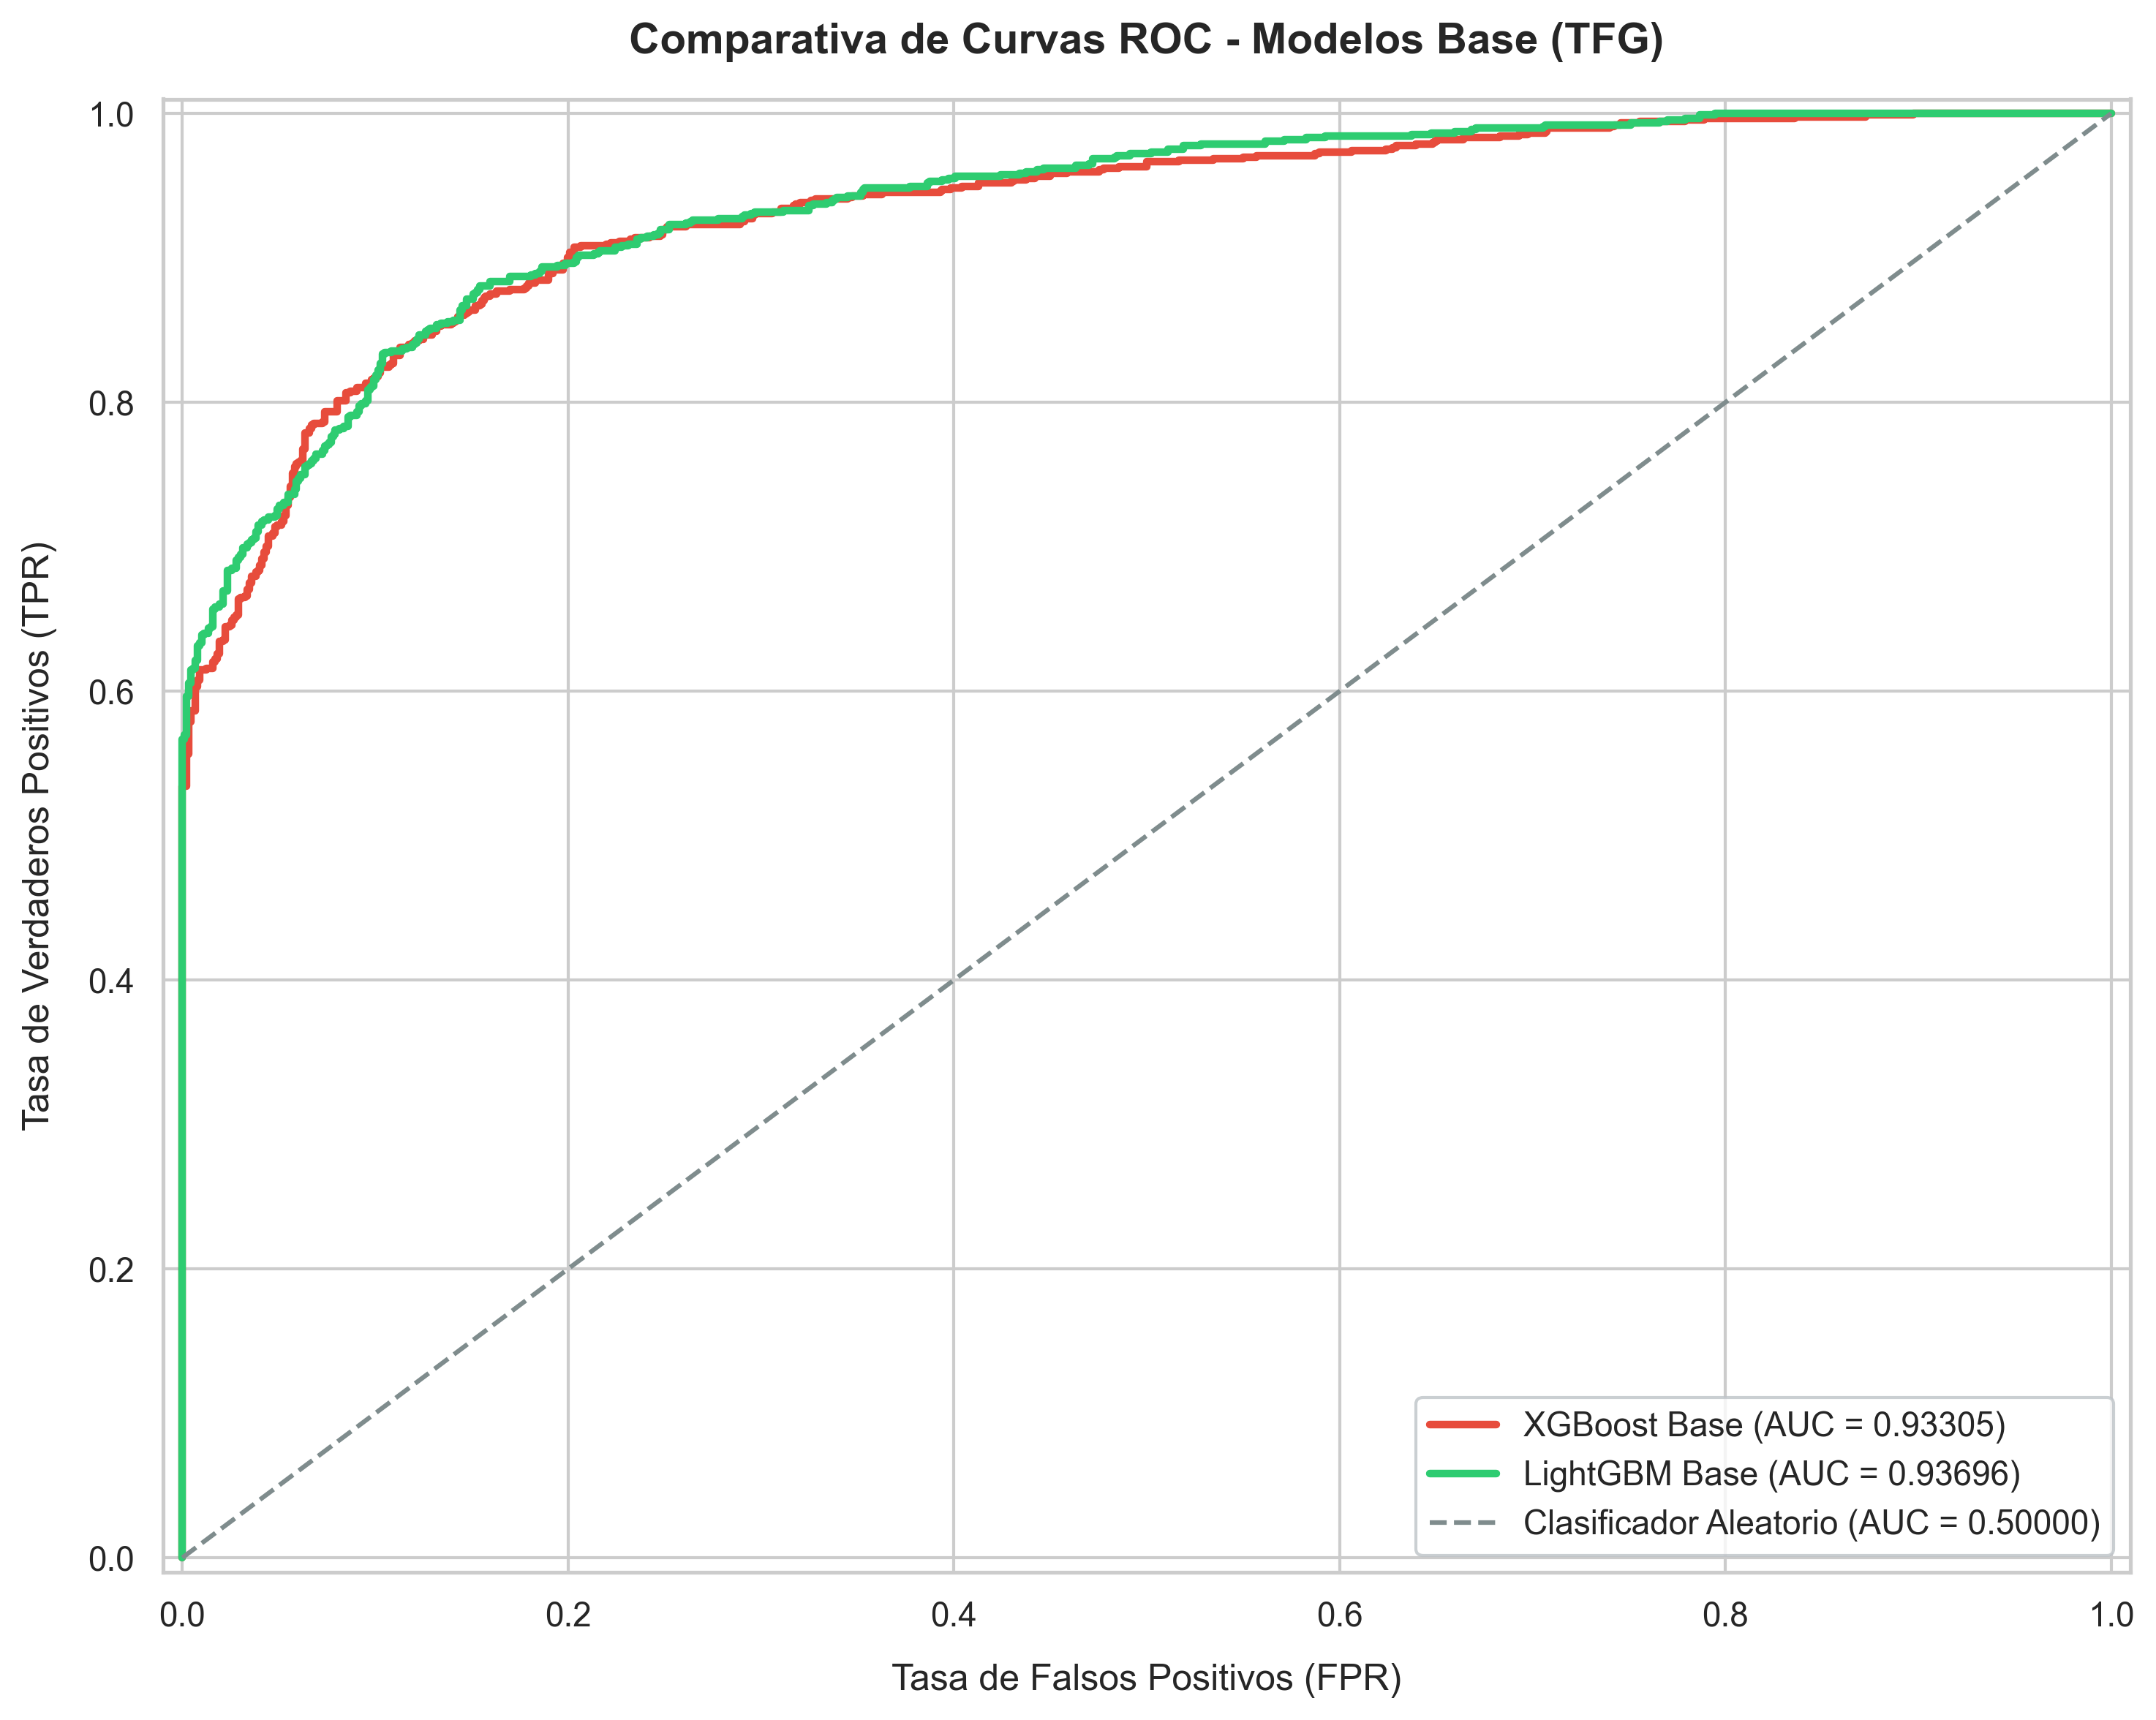

Gráfico comparativo guardado exitosamente en: 12_Curvas_ROC_Modelos_Base.png


In [7]:

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_proba_lgb)


plt.figure(figsize=(10, 8), dpi=300)
sns.set_theme(style="whitegrid")


plt.plot(fpr_xgb, tpr_xgb, color='#e74c3c', lw=2.5, label=f'XGBoost Base (AUC = {auc_xgb:.5f})')
plt.plot(fpr_lgb, tpr_lgb, color='#2ecc71', lw=2.5, label=f'LightGBM Base (AUC = {auc_lgb:.5f})')


plt.plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, linestyle='--', label='Clasificador Aleatorio (AUC = 0.50000)')


plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12, labelpad=10)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12, labelpad=10)
plt.title('Comparativa de Curvas ROC - Modelos Base (TFG)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11, frameon=True, facecolor='white', edgecolor='#bdc3c7')


ROC_FIG_PATH = FIG_DIR / "12_Curvas_ROC_Modelos_Base.png"
plt.tight_layout()
plt.savefig(ROC_FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico comparativo guardado exitosamente en: {ROC_FIG_PATH.name}")